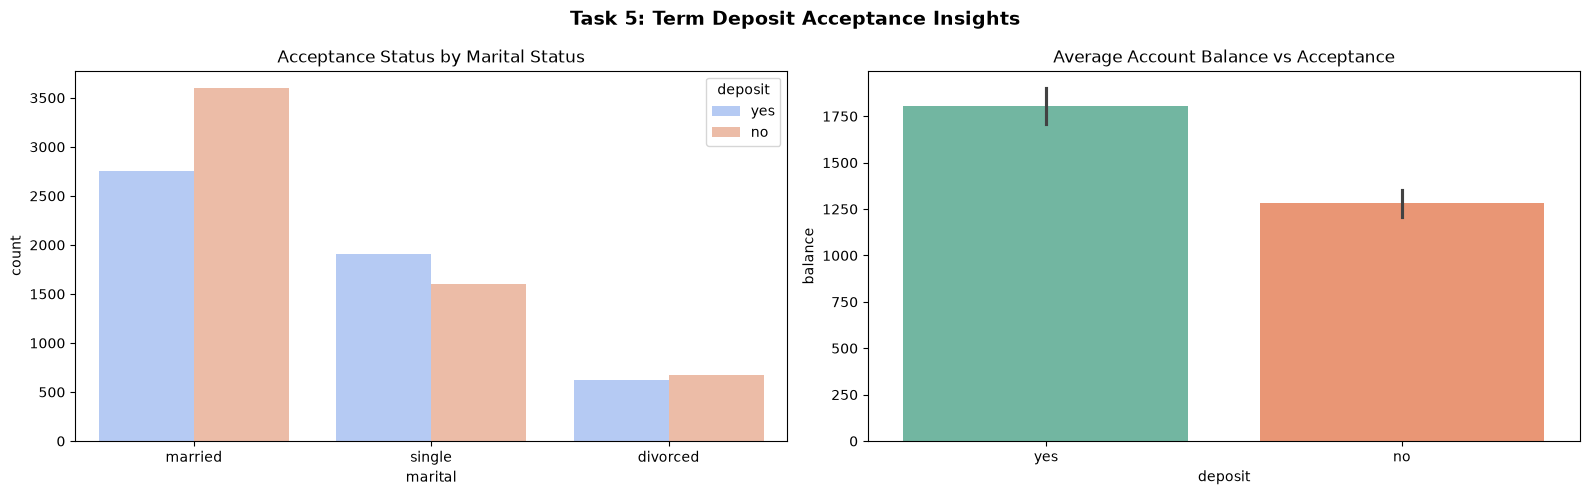

=== Task 5: Classification Report ===
Accuracy: 0.7716

              precision    recall  f1-score   support

           0       0.83      0.71      0.76      1166
           1       0.73      0.84      0.78      1067

    accuracy                           0.77      2233
   macro avg       0.78      0.77      0.77      2233
weighted avg       0.78      0.77      0.77      2233



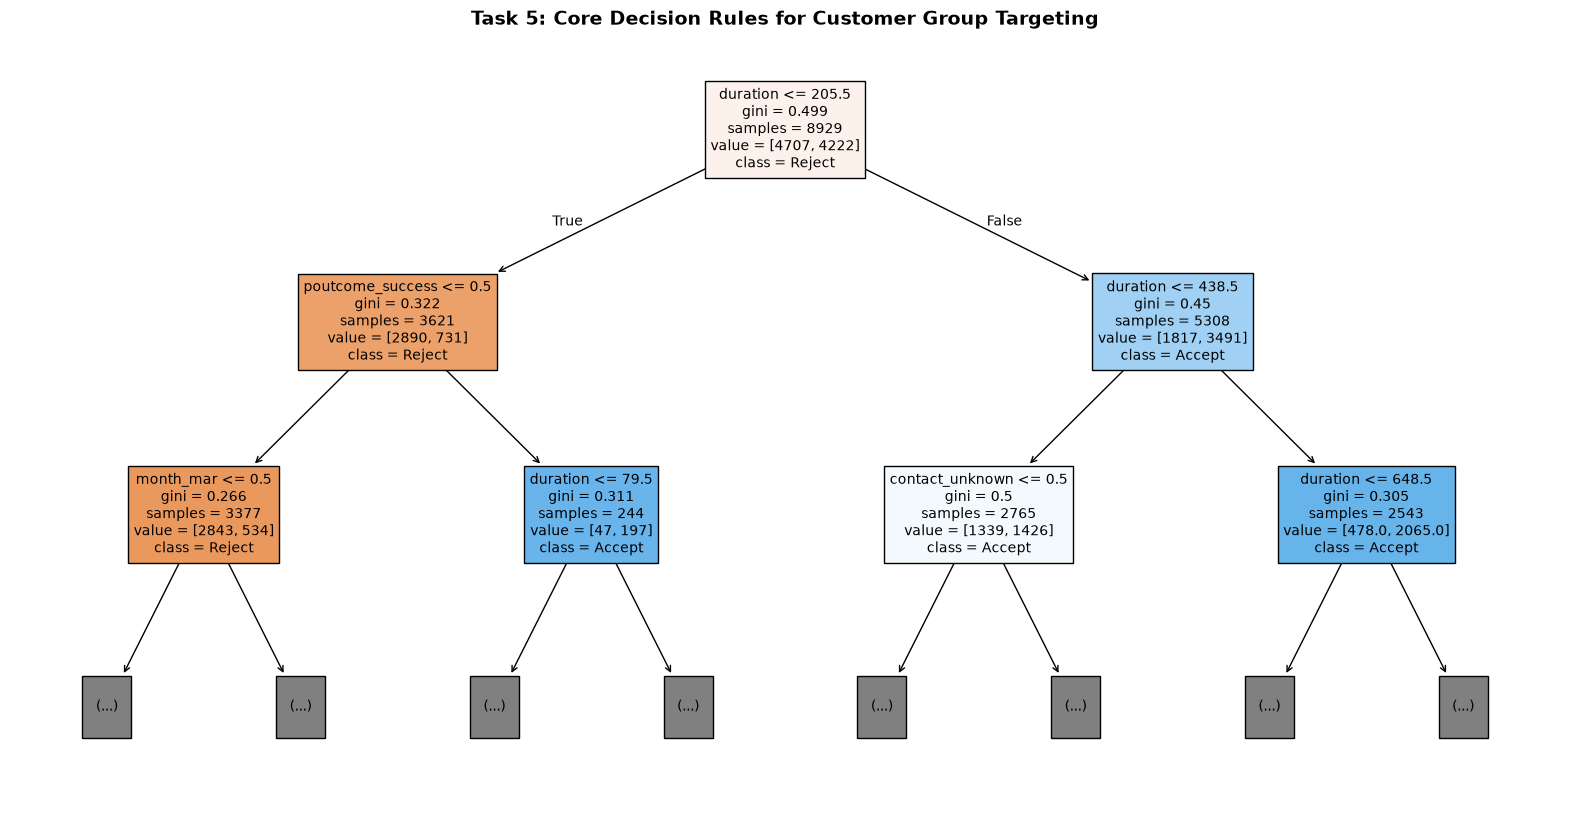

In [8]:
# ==============================================================================
# Task 5: Personal Loan Acceptance Prediction (Bank Marketing)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
df_bank = pd.read_csv("bank.csv")

# 1. Basic Data Exploration
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Task 5: Term Deposit Acceptance Insights", fontsize=14, weight='bold')
sns.countplot(data=df_bank, x='marital', hue='deposit', palette='coolwarm', ax=axes[0])
axes[0].set_title("Acceptance Status by Marital Status")
sns.barplot(data=df_bank, x='deposit', y='balance', palette='Set2', ax=axes[1], hue='deposit', legend=False)
axes[1].set_title("Average Account Balance vs Acceptance")
plt.tight_layout()
plt.show()

# 2. Preprocessing & One-Hot Encoding
X_bank = df_bank.drop(columns=['deposit'])
y_bank = df_bank['deposit'].apply(lambda x: 1 if x == 'yes' else 0)

categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
X_bank = pd.get_dummies(X_bank, columns=categorical_features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_bank, y_bank, test_size=0.2, random_state=42)

# 3. Train Decision Tree Classifier
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)  # Limited depth for clarity & analysis
tree_model.fit(X_train, y_train)

# 4. Analyze Results and Extrapolate Insights
y_pred = tree_model.predict(X_test)
print("=== Task 5: Classification Report ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

# 5. Visualize Top Nodes of Decision Tree to Extract Business Rules
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X_bank.columns, class_names=['Reject', 'Accept'], filled=True, max_depth=2, fontsize=10)
plt.title("Task 5: Core Decision Rules for Customer Group Targeting", fontsize=14, weight='bold')
plt.show()
